**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Segundo Examen Parcial**

*18 de noviembre, 2025*




---


Nombre y Apellido: Alexander Ballera

---



Número de registro: 919064

---



**Abajo de esta línea, importá/instalá todas las *libraries* que consideres relevantes para la resolución de este examen.**

In [1487]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy_financial as nf

**Funciones útiles**

In [1488]:
# Valor máximo de las ejes de coordenadas para mejor visualización
def x_y_max (value, factor, eje):
    value = int(float(value))
    return value*factor if (eje == 'x') else (value + factor)

In [1489]:
# Fórmula de Equivalencia
def equivalencia(i_t1, t2, t1):
    return (1 + i_t1) ** (t2 / t1) - 1

In [1490]:
# Período de recuperación descontado
def payback_desc(flujos, rate):
    acum_desc = 0
    prd = None
    inversion_inicial = abs(flujos[0])
    
    for t in range(1, len(flujos)):
        # Descontar el flujo de caja actual
        discounted_flow = flujos[t] / (1 + rate)**t
        acum_desc += discounted_flow

        # Verificar si el flujo de caja descontado acumulado es mayor o igual a la inversión inicial
        if acum_desc >= inversion_inicial:
            # Si es así, calcular el período de recuperación descontado
            remaining_investment = inversion_inicial - (acum_desc - discounted_flow)
            prd = t - 1 + (remaining_investment / discounted_flow)
            break
    
    return prd

## Unidad 4

### Ejercicio 1

Supongamos que una empresa opera en un mercado y tiene las siguientes funciones:

- Función de Ingreso Marginal ($IMg$): $$ IMg(q) = 150 - 0.05 \cdot q $$

  donde $q$ es la cantidad producida.

- Función de Costo Marginal ($CMg$): $$ CMg(q) = 0.003 \cdot q^2 - 0.4 \cdot q + 80 $$

Además, se sabe que el costo fijo de la empresa es de $\$2000$.

**Integración I**

- Recuperar la función de Ingreso Total, $I(q)$, asumiendo que el ingreso total es cero cuando la cantidad producida es cero: $I(0) = 0$.

In [1491]:
# Paso 1: Defino variables simbólicas
q = sp.symbols('q', positive=True)
q

q

In [1492]:
# Paso 2: Defino la función de Ingreso Marginal
IMg = 150.0 - 0.05*q
IMg

150.0 - 0.05*q

In [1493]:
# Paso 3: Integro para obtener la función de Ingreso Total con I(0) = 0
# como condición inicial, por lo que no agrego constante de integración (F)
I = sp.integrate(IMg, q)
I = sp.simplify(I)
I

q*(150.0 - 0.025*q)

In [1494]:
# Verifico que IMg sea la derivada de IT
IMg_check = sp.diff(I, q)
IMg_check.simplify() == IMg.simplify()  # Debe ser igual

True

- Recuperar la función de Costo Total, $C(q)$.

In [1495]:
# Paso 1: Defino las variables simbólicas: Costo Total C y Costo Fijo F
C, F = sp.symbols('C F')
C, F

(C, F)

In [1496]:
# Paso 2: Defino la función de Ingreso Marginal
CMg = 0.003*q**2 - 0.4*q + 80.0
CMg

0.003*q**2 - 0.4*q + 80.0

In [1497]:
# Paso 3: Integgro la función de Costo Marginal para obtener la función de Costo Total
C = sp.integrate(CMg, q) + F
C = sp.simplify(C)
C

F + 0.001*q**3 - 0.2*q**2 + 80.0*q

In [1498]:
# Paso 4: Determino la constante de integración F usando la condición C(0) = 2000
condicion = sp.Eq(C.subs(q, 0), 2000.0)
F_value = sp.solve(condicion, F)[0]
print(f'F_value: {F_value:.2f}')

F_value: 2000.00


In [1499]:
# 4.2 Sustituyo C0 = F = 2000.00 en la función de Costo Total
C = C.subs(F, F_value)
C

0.001*q**3 - 0.2*q**2 + 80.0*q + 2000.0

- Calcular la función de Beneficio Total ($B(q)$)

In [1500]:
B = I - C
B = sp.simplify(B)
B

-0.001*q**3 + 0.175*q**2 + 70.0*q - 2000.0

- Encontrar la cantidad óptima ($q^{*}$). Esto es, determinar la cantidad de producción que maximiza el beneficio.

  Recordar: podemos lograr esto igualando el ingreso marginal al costo marginal, $IMg(q) = CMg(q)$, y resolviendo para $q$. Considerar solo valores de $q > 0$.

In [1501]:
q_opt = round(sp.solve(sp.Eq(IMg, CMg), q)[0])
q_opt.evalf()

222.000000000000

- Calcular el Beneficio Máximo, $B^{*}(q)$.

In [1502]:
B_opt = B.subs(q, q_opt)
round(B_opt.evalf(), 2)

11223.65

- Visualizar las funciones de ingreso total, costo total y beneficio total en un mismo gráfico. Visualizar el punto de beneficio máximo. Interpretar el gráfico y sus componentes.

In [1503]:
# Paso 1: Creo un rango de cantidades producidas
# Valor máximo en el eje x para mejor visualización
x_max = int(float(q_opt))
x_max = x_y_max (x_max, 1.75, 'x')

# Valor máximo en el eje y para mejor visualización
y_max = 55000

q_grid = np.linspace(0, x_max, 500)

In [1504]:
# Paso 2: Convierto las funciones simbólicas a funciones numéricas
I_num = sp.lambdify(q, I, modules=['numpy'])
C_num = sp.lambdify(q, C, modules=['numpy'])
B_num = sp.lambdify(q, B, modules=['numpy'])

In [1505]:
# Paso 3: Evalúo las funciones en el rango de cantidades
I_vals = I_num(q_grid)
C_vals = C_num(q_grid)
B_vals = B_num(q_grid)

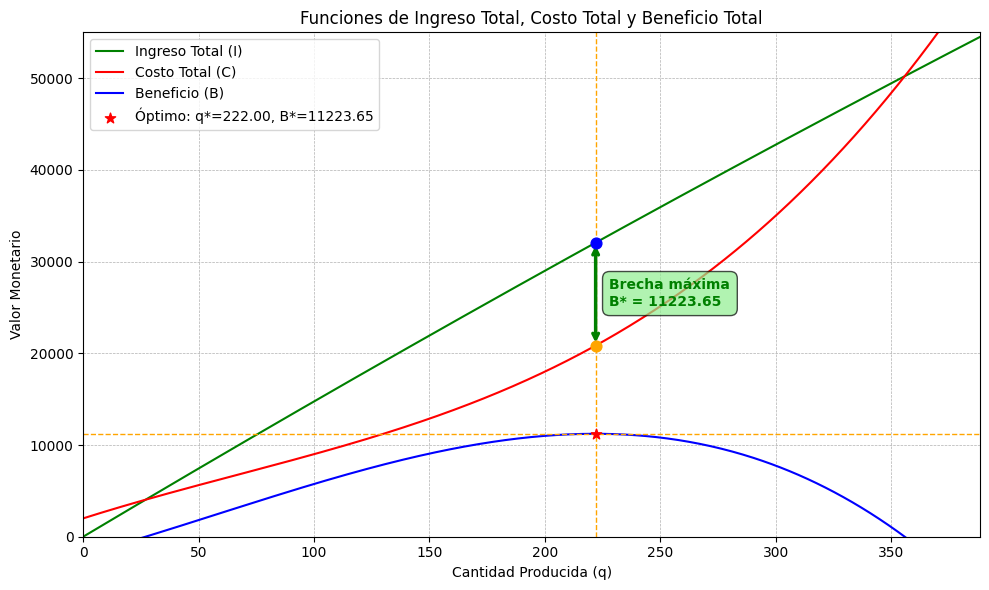

In [1506]:
# Paso 4: Creo el gráfico
fig, axs = plt.subplots(figsize=(10, 6))

# Grafico las funciones
axs.plot(q_grid, I_vals, label='Ingreso Total (I)', color='green')
axs.plot(q_grid, C_vals, label='Costo Total (C)', color='red')
axs.plot(q_grid, B_vals, label='Beneficio (B)', color='blue')

I_opt = float(I_num(q_opt))
C_opt = float(C_num(q_opt))

# Marco el punto óptimo
axs.scatter(q_opt, B_opt, color='red', s=60, label=f'Óptimo: q*={q_opt:.2f}, B*={B_opt:.2f}', marker='*', zorder=5)
axs.scatter(q_opt, I_opt, color='blue', s=60, zorder=4, marker='o')
axs.scatter(q_opt, C_opt, color='orange', s=60, zorder=4, marker='o')

# Líneas de referencias
axs.axvline(x=q_opt, color='orange', linestyle='--', linewidth=1)
axs.axhline(y=B_opt, color='orange', linestyle='--', linewidth=1)

# Flecha bidireccional mostrando la distancia máxima (beneficio)
axs.annotate('', 
            xy=(q_opt, I_opt), 
            xytext=(q_opt, C_opt),
            arrowprops=dict(arrowstyle='<->', color='green', lw=2.5))

# Etiqueta explicativa de la brecha
axs.text(q_opt + 6, (I_opt + C_opt) / 2.1, 
        f'Brecha máxima\nB* = {B_opt:.2f}', 
        fontsize=10, color='green', fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.7))

# Configuro Gráfico
axs.grid(True, which='both', linestyle='--', linewidth=0.5)
axs.set_title('Funciones de Ingreso Total, Costo Total y Beneficio Total')
axs.set_xlabel('Cantidad Producida (q)')
axs.set_ylabel('Valor Monetario')
axs.set_xlim(0, x_max)
axs.set_ylim(0, y_max)
axs.legend()

plt.tight_layout()
plt.show()


**Beneficios Crecientes (IMg > CMg):** Producir la unidad adicional suma más al ingreso de lo que suma al costo. El incentivo de la empresa es producir más, ya que cada unidad extra incrementa el beneficio total. Esto aplica para cantidades menores a la cantidad óptima de producción(222)

**Punto de Maximización (IMg = CMg):** Este es el punto exacto donde la empresa estaria generando el mayor beneficio posible.

**Beneficios Decrecientes (IMg < CMg):** Producir una unidad adicional suma más al costo de lo que suma al ingreso. Esto aplica para cantidades mayores a la cantidad óptima de producción(222). El incentivo de la empresa es reducir la producción.

La zona de beneficios (donde B(q)>0) define el rango operacional donde la empresa puede subsistir. Los puntos donde el ingreso interseca al costo, donde B(q)=0 implica que C(q) = I(q) indican el umbral mínimo que la empresa debe superar para sobrevivir en el mercado.

### Ejercicio 2

Las funciones de oferta y demanda de cierto producto están dadas por:

$$O: p=45+2q$$

$$D:p= 144-q^2$$

**Integración II**

- Determinar el Excedente del Consumidor (EC) y el Excedente del Productor (EP).

In [1507]:
# Paso 1 Planteo y validación
# Las funciones de oferta y demanda ya se encuentran planteadas como funciones inversas
# de precio en función de cantidad. Por lo tanto, no es necesario realizar modificaciones
# adicionales.

# 1.1 Defino las variables simbólicas
p, q = sp.symbols('p q', real=True, positive=True)

In [1508]:
# 1.2 Defino las funciones de oferta y demanda
P_s = 45 + 2*q
P_d = 144 - q**2

print(f"  Demanda: P_d(q) = {P_d}")
print(f"  Oferta:  P_s(q) = {P_s}")

  Demanda: P_d(q) = 144 - q**2
  Oferta:  P_s(q) = 2*q + 45


In [1509]:
# 1.3 Encuentro equilibrio de mercado P_s(q) = P_d(q)
eq_equilibrio = sp.Eq(P_s, P_d)
q_eq = sp.solve(eq_equilibrio, q)[0]
p_eq = P_s.subs(q, q_eq)

print("EQUILIBRIO DEL MERCADO:")
print(f"  Ecuación: {P_d} = {P_s}")
print(f"  q* = {q_eq}")
print(f"  p* = {p_eq}")

EQUILIBRIO DEL MERCADO:
  Ecuación: 144 - q**2 = 2*q + 45
  q* = 9
  p* = 63


- Graficar ambas funciones en un mismo gráfico, donde el eje vertical (ordenadas) debe ser el precio y el horizontal (abscisas) la cantidad.

In [1510]:
# Preparo datos para graficar

# Valor máximo en el eje x para mejor visualización
x_max = int(float(q_eq))
x_max = x_y_max (x_max, 1.5, 'x')

# Valor máximo en el eje y para mejor visualización
y_max = int(float(P_d.subs(q, 0)))
y_max = x_y_max (y_max, 10, 'y')

q_grid = np.linspace(0, x_max, 500)
P_d_lambda = sp.lambdify(q, P_d, 'numpy')
P_s_lambda = sp.lambdify(q, P_s, 'numpy')

Pd_num = P_d_lambda(q_grid)
Ps_num = P_s_lambda(q_grid)


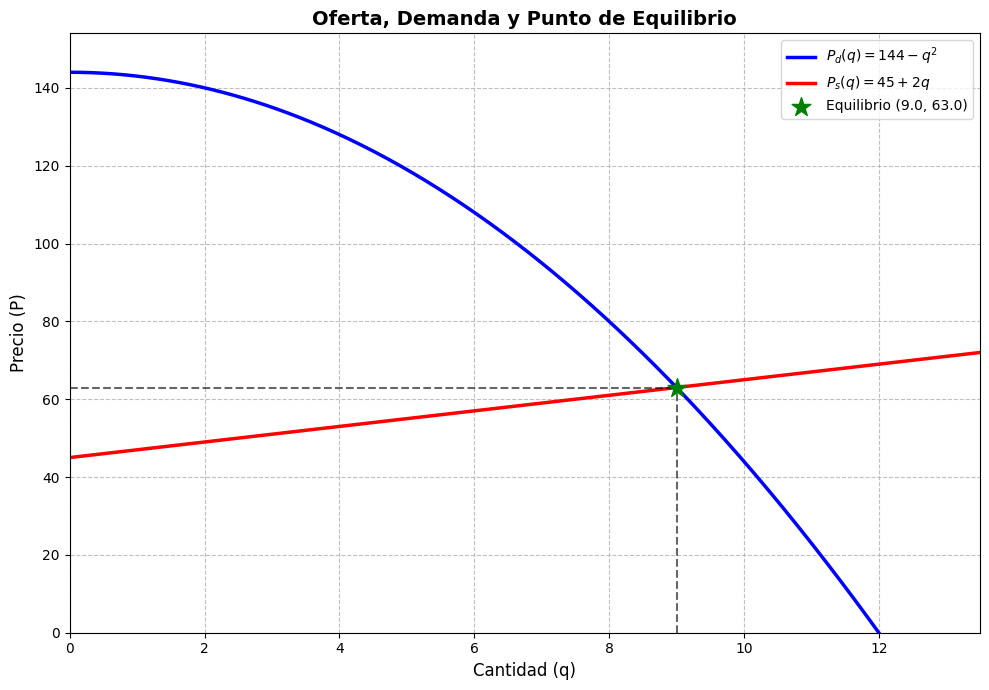

In [1511]:
# Crear gráfico con ETIQUETAS CORRECTAS
plt.figure(figsize=(10, 7))
plt.plot(q_grid, Pd_num, label='$P_d(q) = 144 - q^2$', linewidth=2.5, color='blue')
plt.plot(q_grid, Ps_num, label='$P_s(q) = 45 + 2q$', linewidth=2.5, color='red')

# Punto de equilibrio
plt.scatter([q_eq], [p_eq], s=200, c='green', marker='*', zorder=5, label=f'Equilibrio ({float(q_eq):.1f}, {float(p_eq):.1f})')
plt.vlines(q_eq, 0, p_eq, linestyles='--', color='black', alpha=0.6)
plt.hlines(p_eq, 0, q_eq, linestyles='--', color='black', alpha=0.6)

plt.title('Oferta, Demanda y Punto de Equilibrio', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad (q)', fontsize=12)
plt.ylabel('Precio (P)', fontsize=12)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.8, linestyle='--')
plt.xlim(0, x_max)
plt.ylim(0, y_max)
plt.tight_layout()
plt.show()

- Sombrear las áreas correspondientes a los excedentes encontrados indicando en el gráfico cuál es el excedente del consumidor y cuál el del productor. Interpretar.

In [1512]:
# Paso 2: Excedente del Consumidor y del Productor
# Calculo con antiderivada y barrow para hallar EC y EP

print("INTERPRETACIÓN:")
print("  • EC mide el área entre la curva de demanda y el precio de equilibrio")
print("  • EP mide el área entre el precio de equilibrio y la curva de oferta")
print()
print("OBJETIVOS:")
print(f"  • EC = ∫[0, {q_eq}] [P_d(q) - {p_eq}] dq")
print(f"  • EP = ∫[0, {q_eq}] [{p_eq} - P_s(q)] dq")

INTERPRETACIÓN:
  • EC mide el área entre la curva de demanda y el precio de equilibrio
  • EP mide el área entre el precio de equilibrio y la curva de oferta

OBJETIVOS:
  • EC = ∫[0, 9] [P_d(q) - 63] dq
  • EP = ∫[0, 9] [63 - P_s(q)] dq


In [1513]:
# 2.1 Excedente del Consumidor (EC)
EC = sp.integrate(P_d - p_eq, (q, 0, q_eq))

print(f"EC = {EC}")

EC = 486


In [1514]:
# 2.2 Excedente del Productor (EP)
EP = sp.integrate(p_eq - P_s, (q,0, q_eq))

print(f"EP = {EP}")

EP = 81


In [1515]:
# 2.3 Excedente Total (ET)
ET = EC + EP

print(f"ET = EC + EP = {ET}")

ET = EC + EP = 567


In [1516]:
# 2.4 Preparar datos para graficar

# Valor máximo en el eje x para mejor visualización
x_max = int(float(q_eq))
x_max = x_y_max (x_max, 1.5, 'x')

# Valor máximo en el eje y para mejor visualización
y_max = int(float(P_d.subs(q, 0)))
y_max = x_y_max (y_max, 10, 'y')

q_grid = np.linspace(0, x_max, 500)
P_d_lambda = sp.lambdify(q, P_d, 'numpy')
P_s_lambda = sp.lambdify(q, P_s, 'numpy')

Pd_num = P_d_lambda(q_grid)
Ps_num = P_s_lambda(q_grid)


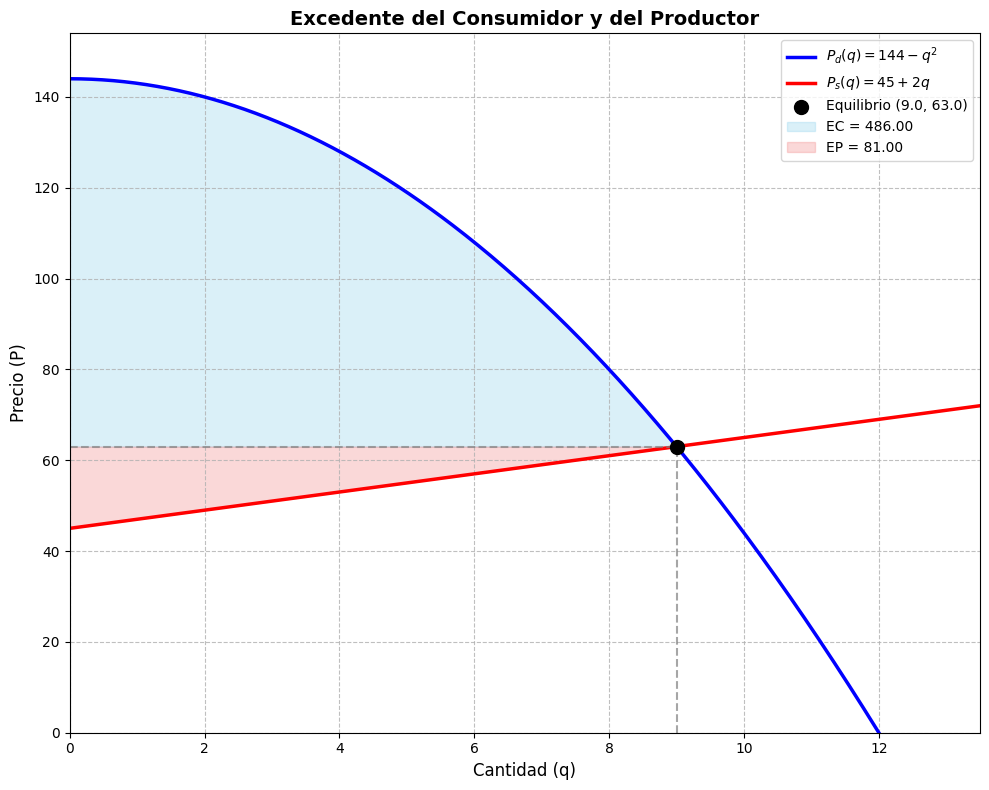

In [1517]:
# Crear gráfico con ETIQUETAS CORRECTAS
plt.figure(figsize=(10, 8))
plt.plot(q_grid, Pd_num, label='$P_d(q) = 144 - q^2$', linewidth=2.5, color='blue')
plt.plot(q_grid, Ps_num, label='$P_s(q) = 45 + 2q$', linewidth=2.5, color='red')

# Punto de equilibrio
plt.scatter([q_eq], [p_eq], s=100, c='black', zorder=5, label=f'Equilibrio ({float(q_eq):.1f}, {float(p_eq):.1f})')
plt.vlines(q_eq, 0, p_eq, linestyles='--', color='gray', alpha=0.7)
plt.hlines(p_eq, 0, q_eq, linestyles='--', color='gray', alpha=0.7)

# Sombrear excedentes
condicion = (q_grid <= float(q_eq)).tolist()
plt.fill_between(q_grid, Pd_num, float(p_eq), where=condicion, 
                 alpha=0.3, color='skyblue', label=f'EC = {float(EC):.2f}')
plt.fill_between(q_grid, float(p_eq), Ps_num, where=condicion, 
                 alpha=0.3, color='lightcoral', label=f'EP = {float(EP):.2f}')

plt.title('Excedente del Consumidor y del Productor', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad (q)', fontsize=12)
plt.ylabel('Precio (P)', fontsize=12)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.8, linestyle='--')
plt.xlim(0, x_max)
plt.ylim(0, y_max)
plt.tight_layout()
plt.show()

### CONCLUSIONES

En equilibrio: q* = 9.00 unidades, p* = $63.00

**Excedente del consumidor (EC)** es el ahorro o el beneficio neto que reciben los consumidores. Representa la diferencia entre lo que estaban dispuestos a pagar por el bien (el valor real que le asignaban, dado por la curva Pd​) y lo que realmente pagaron (el precio de equilibrio). Valor: $486.00

**Excedente del Productor (EP)** representa el beneficio que obtienen los productores por vender a un precio mayor al mínimo que aceptarían (su costo marginal). Valor: $81.00

**Excedente Total (ET):** Mide el bienestar social total generado por este mercado. Un mercado competitivo maximiza este excedente. Valor: $567.00

Teniendo en cuenta las definiciones lo que nos indica el grafico es que el excedente del consumidor es mayor que el excedente del productor por lo que en la situacion que nos plantea el enunciado el consumidor estaria siendo el sujeto mas beneficiado en estas condiciones llevandose la porcion mas grande de bienestar.


### Ejercicio 3

Dada la función de Costo marginal

$$CMg=0.01-\dfrac{500}{x^{2}}$$

**Integración III**


- Calcular el costo total de producir 100 unidades si el costo fijo es $F = 50$.

In [1518]:
# Integro para hallar la función de Costo Total
# Paso 1: Defino las variables simbólicas
q = sp.symbols('q', positive=True)
F = sp.symbols('F')
q, F

(q, F)

In [1519]:
# Paso 2: Defino la función de Costo Marginal
CMg = 0.01 - (500.0 / q**2)
CMg

0.01 - 500.0/q**2

In [1520]:
# Paso 3: Integro la función de Ingreso Marginal para obtener la función de Ingreso Total
C = sp.integrate(CMg, q) + F
C = sp.simplify(C)
C

F + 0.01*q + 500.0/q

In [1521]:
# Paso 4: Sustituyo F en la función de Costo Total
C = C.subs(F, 50.0)
C.simplify()
C

0.01*q + 50.0 + 500.0/q

In [1522]:
# Paso 5: Sustituyo q = 100 en la función de Costo Total
C_100 = C.subs(q, 100.0)
print(f"""
      El costo de producir 100 unidades con un
      costo fijo de 50,0 unidades monetarias es
      C(100) = {C_100:.2f}
      """)


      El costo de producir 100 unidades con un
      costo fijo de 50,0 unidades monetarias es
      C(100) = 56.00
      


- Calcular, a través de una integral definida, el costo total variable acumulado entre 30 y 45 unidades.

In [1523]:
# Costo total variable acumulado entre 30 y 45 unidades
C_45 = C.subs(q, 45.0)
C_30 = C.subs(q, 30.0)
C_variable_30_45 = C_45 - C_30
round(C_variable_30_45, 2)


-5.41

In [1524]:
# Valido con CMg
test_C_variable_30_45 = sp.integrate(CMg, (q, 30, 45))
print(f"{test_C_variable_30_45:.2f} == {C_variable_30_45:.2f}")
print(f"¿Coinciden los cálculos? {round(test_C_variable_30_45, 2) == round(C_variable_30_45, 2)}")    

-5.41 == -5.41
¿Coinciden los cálculos? True


In [1525]:
print(f"""
El costo total variable acumulado entre 30 y 45 unidades es de
{C_variable_30_45:.2f}
      """)


El costo total variable acumulado entre 30 y 45 unidades es de
-5.41
      


- Graficar costo total y costo marginal. Interpretar el gráfico.

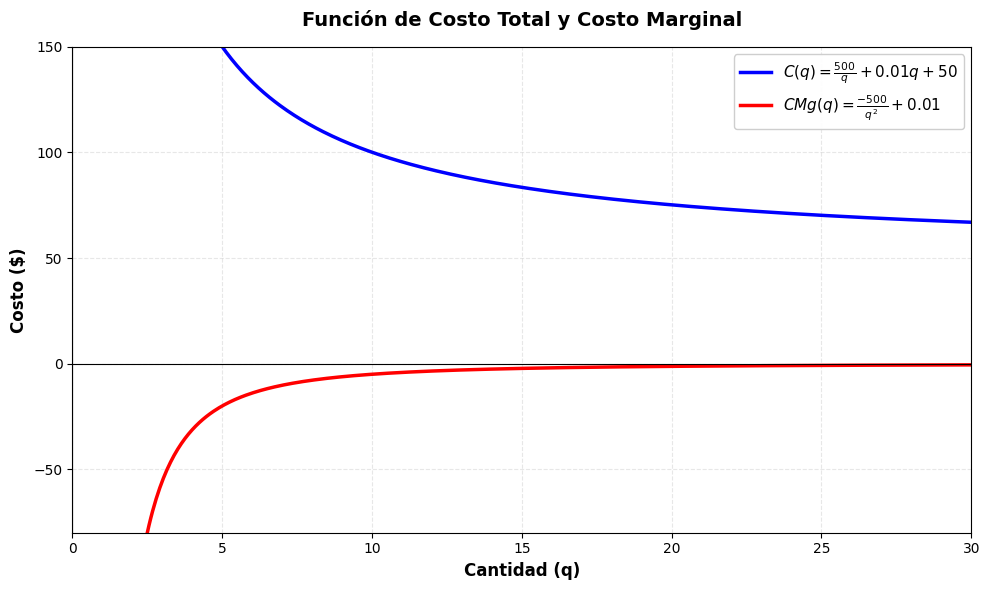

In [1526]:
# Preparar datos para graficar
q_grid = np.linspace(0.1, 30, 500)
C_num = sp.lambdify(q, C)(q_grid)
CMg_num = sp.lambdify(q, CMg)(q_grid)

# Crear figura con tamaño adecuado
plt.figure(figsize=(10, 6))

# Graficar costo total y costo marginal
plt.plot(q_grid, C_num, label='$C(q) = \\frac{500}{q} + 0.01q + 50$', 
         linewidth=2.5, color='blue')
plt.plot(q_grid, CMg_num, label='$CMg(q) = \\frac{-500}{q^2} + 0.01$', 
         linewidth=2.5, color='red')

# Líneas de referencia
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

# Configuración del gráfico
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlabel('Cantidad (q)', fontsize=12, fontweight='bold')
plt.ylabel('Costo ($)', fontsize=12, fontweight='bold')
plt.title('Función de Costo Total y Costo Marginal', 
         fontsize=14, fontweight='bold', pad=15)
plt.legend(fontsize=11, loc='upper right', framealpha=0.95)
plt.xlim(0, 30)
plt.ylim(-80, 150)

plt.tight_layout()
plt.show()

In [1527]:
# Interpretación
print(f"\n ANÁLISIS:\n")

print("1. Función de Costo Total C(q):")
print("   • Curva azul con forma hiperbólica")
print("   • Decrece rápidamente al principio, luego crece linealmente")
print("   • El costo fijo ($50) genera una asíntota vertical en q=0")
print("   • Para q=100: C(100) = $60.00")

print("\n2. Función de Costo Marginal CMg(q):")
print("   • Curva roja que empieza muy negativa y se vuelve positiva")
print("   • Forma de hipérbola: -500/q² + 0.01")
print("   • Se acerca asintóticamente a 0.01 cuando q→∞")
print("   • Cruza el eje horizontal (CMg=0) alrededor de q≈22")

print("\n INTERPRETACIÓN:")
print("   • Costos marginales NEGATIVOS (q<22): cada unidad adicional")
print("     REDUCE el costo total debido a economías de escala")
print("   • Costos marginales POSITIVOS (q>22): comportamiento normal")
print("     donde producir más aumenta el costo total")
print("   • El punto mínimo de C(q) ocurre donde CMg=0")

print("\n CONCLUSIÓN:")
print("   Los costos fijos dominan la estructura de costos inicialmente.")


 ANÁLISIS:

1. Función de Costo Total C(q):
   • Curva azul con forma hiperbólica
   • Decrece rápidamente al principio, luego crece linealmente
   • El costo fijo ($50) genera una asíntota vertical en q=0
   • Para q=100: C(100) = $60.00

2. Función de Costo Marginal CMg(q):
   • Curva roja que empieza muy negativa y se vuelve positiva
   • Forma de hipérbola: -500/q² + 0.01
   • Se acerca asintóticamente a 0.01 cuando q→∞
   • Cruza el eje horizontal (CMg=0) alrededor de q≈22

 INTERPRETACIÓN:
   • Costos marginales NEGATIVOS (q<22): cada unidad adicional
     REDUCE el costo total debido a economías de escala
   • Costos marginales POSITIVOS (q>22): comportamiento normal
     donde producir más aumenta el costo total
   • El punto mínimo de C(q) ocurre donde CMg=0

 CONCLUSIÓN:
   Los costos fijos dominan la estructura de costos inicialmente.


## Unidad 5

### Ejercicio 4

A partir del cash flow MENSUAL establecido en la línea de código propuesta a continuación y considerando un costo de capital anual del 11%, realice un análisis que contenga:

- Métricas financieras: VAN, TIR, TIRM y Payback Descontado (*Período de Recuperación Descontado, PRD*) e interprete cada una de ellas.

In [1528]:
inversion_inicial = -50000
cash_flows = [
    10000, -12000, 15000, 18000, 20000, 22000, 25000, 28000, -30000, 32000,
    -5000, 10000, 13000, 16000, -19000, 21000, -24000, 27000, -23000, 33000,
    -8000, 11000, -14000, 17000, 20000, 23000, 26000, -25000, 32000
]
nuevo_cash_flow = [inversion_inicial] + cash_flows

In [1529]:
# Tasa de descuento anual
TEA = 0.11  # 11% anual

# Definir la tasa de descuento mensual
r = equivalencia(TEA, 30, 365)
print(f"Tasa efectiva mensual equivalente: TEA {TEA:.2%} → TEM {r:.4%}")

Tasa efectiva mensual equivalente: TEA 11.00% → TEM 0.8614%


In [1530]:
# VAN
van = nf.npv(r, nuevo_cash_flow)
print(f"Tasa de descuento mensual utilizada: {r:.4%}")
print(f"El proyecto genera un valor actual neto de ${van:,.2f}.")

Tasa de descuento mensual utilizada: 0.8614%
El proyecto genera un valor actual neto de $179,241.37.


**Interpretación:** El VAN es mayor que cero (VAN>0). Esto implica que el proyecto creará valor para la empresa, ya que el valor presente de todos los flujos de caja futuros supera la inversión inicial. Segun el VAN el proyecto es rentable

In [1531]:
# TIR
tir = nf.irr(values=nuevo_cash_flow)
tir_anual = (1 + tir)**12 - 1
costo_capital_anual = (1 + r)**12 - 1

print(f"TIR mensual: {tir:.2%}")
print(f"TIR anual: {tir_anual:.2%}")

print(f"{'✅ VIABLE' if tir_anual > costo_capital_anual else '❌ NO VIABLE'}: La TIR ({tir_anual:.2%}) {'supera' if tir_anual > costo_capital_anual else 'es menor que'} el costo de capital ({costo_capital_anual:.2%}).")

TIR mensual: 19.65%
TIR anual: 761.24%
✅ VIABLE: La TIR (761.24%) supera el costo de capital (10.84%).


**Interpretacion:** La TIR es mucho mayor que la tasa de descuento (19,65% > 0,86%). Esto significa que la rentabilidad intrínseca del proyecto está por encima del rendimiento mínimo exigido. Segun el TIR el proyecto es rentable

In [1532]:
# TIRM
# finance_rate: costo de financiar flujos negativos (costo de capital)
# reinvest_rate: tasa de reinversión de flujos positivos (costo de oportunidad)
tirm = nf.mirr(values=nuevo_cash_flow, finance_rate=tir, reinvest_rate=r)
tirm_anual = (1 + tirm)**12 - 1

print(f"TIRM mensual: {tirm:.4%}")
print(f"TIRM anual: {tirm_anual:.2%}")

print(f"\nInterpretación: La rentabilidad modificada es {tirm_anual:.2%} anual.")
print(f"Es más conservadora que la TIR porque asume reinversión al costo de capital.")
print(f"{'✅ VIABLE' if tirm_anual > costo_capital_anual else '❌ NO VIABLE'}: TIRM ({tirm_anual:.2%}) {'>' if tirm_anual > costo_capital_anual else '<'} Costo de Capital ({costo_capital_anual:.2%}).")

TIRM mensual: 6.8672%
TIRM anual: 121.89%

Interpretación: La rentabilidad modificada es 121.89% anual.
Es más conservadora que la TIR porque asume reinversión al costo de capital.
✅ VIABLE: TIRM (121.89%) > Costo de Capital (10.84%).


**Interpretacion:** La TIRM es mayor que la tasa de descuento (6,86%>0,86%). Esto indica que la rentabilidad efectiva del proyecto, asumiendo que tanto los flujos de caja positivos se reinvierten a una tasa de reinversion como que los flujos de caja negativos se financian a una tasa de financiamiento, supera al costo de capital. Segun el TIRM el proyecto es rentable.

In [1533]:
# Período de Recuperación Descontado (PRD) - Fórmula corregida
prd = payback_desc(nuevo_cash_flow, r)
print(f"📊 Payback descontado: {prd:.2f} meses ({prd/12:.2f} años)")

print(f"\n🔍 INTERPRETACIÓN DEL PRD:")
print(f"   • Tiempo para recuperar inversión considerando valor temporal del dinero")
print(f"   • Se recupera la inversión inicial en {prd:.2f} meses")
print(f"   • Un PRD corto ({prd:.2f} meses) indica MENOR RIESGO temporal")
print(f"   • Método más preciso que payback simple (considera descuento)")
print(f"   • Útil para comparar proyectos con diferentes perfiles de riesgo temporal")

print(f"\n⚖️ CRITERIO DE DECISIÓN:")
limite_prd = 24  # 2 años como límite ejemplo
if prd <= limite_prd:
    print(f"   ✅ ACEPTABLE: PRD ({prd:.1f} meses) ≤ Límite ({limite_prd} meses)")
else:
    print(f"   ❌ RIESGOSO: PRD ({prd:.1f} meses) > Límite ({limite_prd} meses)")

📊 Payback descontado: 5.03 meses (0.42 años)

🔍 INTERPRETACIÓN DEL PRD:
   • Tiempo para recuperar inversión considerando valor temporal del dinero
   • Se recupera la inversión inicial en 5.03 meses
   • Un PRD corto (5.03 meses) indica MENOR RIESGO temporal
   • Método más preciso que payback simple (considera descuento)
   • Útil para comparar proyectos con diferentes perfiles de riesgo temporal

⚖️ CRITERIO DE DECISIÓN:
   ✅ ACEPTABLE: PRD (5.0 meses) ≤ Límite (24 meses)


**Interpretacion:** Indica que la suma acumulada de los flujos de caja descontados logra igualar a la inversión inicial en el periodo analizado. Por lo que en 5,03 meses recupero lo invertido inicialmente en el proyecto

- Grafique el flujo de fondos.

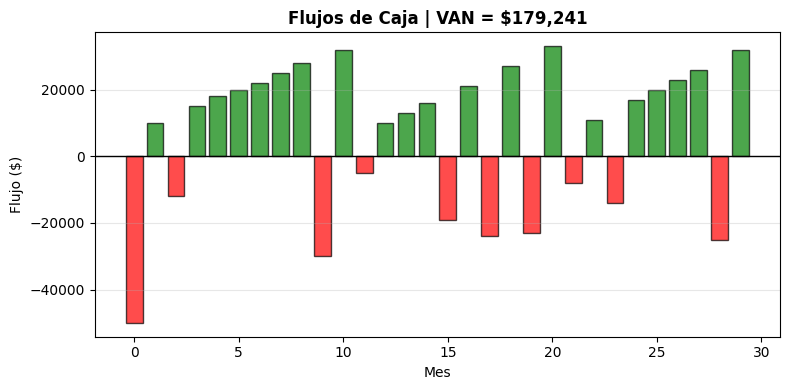

ANÁLISIS DEL FLUJO DE CAJA:
• Inversión inicial: $-50,000
• Número de períodos: 29 meses
• Flujos positivos: 20
• Flujos negativos: 9
• Flujo promedio: $8,931
• Flujo máximo: $33,000
• Flujo mínimo: $-30,000

El proyecto presenta:
- Volatilidad significativa con flujos tanto positivos como negativos
- Tendencia general positiva que compensa la inversión inicial
- VAN positivo de $179,241 indica viabilidad del proyecto


In [1534]:
# Visualización
years = list(range(len(nuevo_cash_flow)))
plt.figure(figsize=(8, 4))
colores = ['red' if f < 0 else 'green' for f in nuevo_cash_flow]
plt.bar(years, nuevo_cash_flow, color=colores, alpha=0.7, edgecolor='black')
plt.axhline(0, color='black', linewidth=1)
plt.title(f'Flujos de Caja | VAN = ${van:,.0f}', fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Flujo ($)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Descripción del flujo de caja
print("ANÁLISIS DEL FLUJO DE CAJA:")
print("=" * 50)
print(f"• Inversión inicial: ${inversion_inicial:,}")
print(f"• Número de períodos: {len(cash_flows)} meses")
print(f"• Flujos positivos: {len([f for f in cash_flows if f > 0])}")
print(f"• Flujos negativos: {len([f for f in cash_flows if f < 0])}")
print(f"• Flujo promedio: ${np.mean(cash_flows):,.0f}")
print(f"• Flujo máximo: ${max(cash_flows):,}")
print(f"• Flujo mínimo: ${min(cash_flows):,}")
print("\nEl proyecto presenta:")
print("- Volatilidad significativa con flujos tanto positivos como negativos")
print("- Tendencia general positiva que compensa la inversión inicial")
print(f"- VAN positivo de ${van:,.0f} indica viabilidad del proyecto")

- Grafique el VAN a diferentes tasas de descuento de costo de capital. Marque en dicho gráfico la TIR. Explique el gráfico y sus componentes.

Tasa Interna de Retorno (TIR): 19.65%
Tasa Interna de Retorno Modificada (TIRM): 6.87%


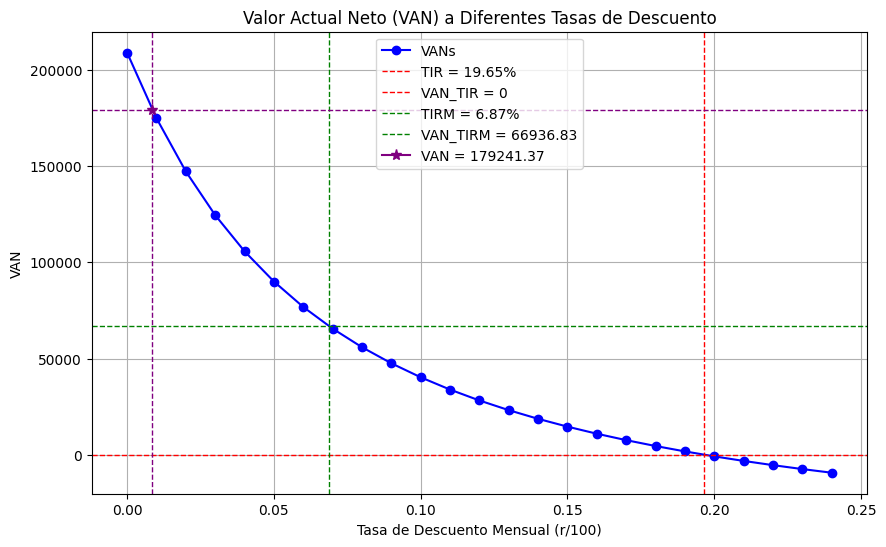


ANÁLISIS DEL GRÁFICO VAN vs TASA:
• La curva azul muestra cómo el VAN decrece al aumentar la tasa de descuento
• La línea roja marca la TIR: punto donde VAN = 0
• La línea verde marca la TIRM: versión más conservadora
• Para tasas menores a la TIR: VAN > 0 (proyecto viable)
• Para tasas mayores a la TIR: VAN < 0 (proyecto no viable)
• Con nuestra tasa del 0.86% mensual, el VAN es $179,241

Conclusión: El proyecto es rentable mientras el costo de capital
sea menor al 19.65% mensual (761.24% anual)


In [1535]:
# --- Calcular TIR y TIRM ---
flujos = nuevo_cash_flow.copy()
# tir = nf.irr(flujos)
# tirm = nf.mirr(flujos, rfinanciamiento, rreinversion)
van_tirm = nf.npv(tirm, nuevo_cash_flow)

print(f"Tasa Interna de Retorno (TIR): {tir:.2%}")
print(f"Tasa Interna de Retorno Modificada (TIRM): {tirm:.2%}")

# --- Crear rango de tasas para VAN ---
tasas_descuento = np.arange(0, max(tir*1.2, 0.25), 0.01) # es muy importante agregar el max porque sino el grafico no encuentra el corte con la tir, queda desescalado.
# --- Calcular VAN para cada tasa ---
van_por_tasa = [nf.npv(tasa, flujos) for tasa in tasas_descuento]

# --- Graficar VAN vs Tasa ---
plt.figure(figsize=(10, 6))
plt.plot(tasas_descuento, van_por_tasa, marker='o', linestyle='-', color='blue', label='VANs')

# Marcar TIR y TIRM en el gráfico
plt.axvline(tir, color='red', linestyle='--', linewidth=1, label=f"TIR = {tir:.2%}")
plt.axhline(0, color='red', linestyle='--', linewidth=1, label=f"VAN_TIR = 0")
plt.axvline(tirm, color='green', linestyle='--', linewidth=1, label=f"TIRM = {tirm:.2%}")
plt.axhline(van_tirm, color='green', linestyle='--', linewidth=1, label=f"VAN_TIRM = {van_tirm:.2f}")

# grafico el punto del VAN del proyecto
plt.plot(r, van, marker='*', color='purple', markersize=8, label=f"VAN = {van:.2f}")
plt.axvline(r, color='purple', linestyle='--', linewidth=1)
plt.axhline(van, color='purple', linestyle='--', linewidth=1)

# --- Etiquetas y formato ---
plt.title('Valor Actual Neto (VAN) a Diferentes Tasas de Descuento')
plt.xlabel('Tasa de Descuento Mensual (r/100)')
plt.ylabel('VAN')
plt.grid(True)
plt.legend()
plt.show()

# Descripción del gráfico VAN vs Tasa
print("\nANÁLISIS DEL GRÁFICO VAN vs TASA:")
print("=" * 50)
print("• La curva azul muestra cómo el VAN decrece al aumentar la tasa de descuento")
print("• La línea roja marca la TIR: punto donde VAN = 0")
print("• La línea verde marca la TIRM: versión más conservadora")
print("• Para tasas menores a la TIR: VAN > 0 (proyecto viable)")
print("• Para tasas mayores a la TIR: VAN < 0 (proyecto no viable)")
print(f"• Con nuestra tasa del {r*100:.2f}% mensual, el VAN es ${van:,.0f}")
print("\nConclusión: El proyecto es rentable mientras el costo de capital")
print(f"sea menor al {tir:.2%} mensual ({tir_anual:.2%} anual)")


- Considere que el gerente financiero pronostica un aumento posible del costo de capital a la hora de iniciar el proyecto conformando un costo total del 17% anual. Realice el análisis nuevamente e interprete los resultados.

In [1536]:
# CORRECCIÓN: Conversión correcta del nuevo costo de capital
TEA_2 = 0.17  # 17% anual
r2 = (1 + TEA_2)**(30/365) - 1  # Tasa efectiva mensual
print(f"✅ Nueva TEA: {TEA_2:.2%} → Nueva TEM: {r2:.4%}")

van2 = nf.npv(rate=r2, values=nuevo_cash_flow)
tir2 = nf.irr(values=nuevo_cash_flow)  # TIR no cambia (característica del proyecto)
tirm2 = nf.mirr(values=nuevo_cash_flow, finance_rate=tir2, reinvest_rate=r2)
prd2 = payback_desc(nuevo_cash_flow, r2)

✅ Nueva TEA: 17.00% → Nueva TEM: 1.2988%


In [1537]:
print(f"VAN con nueva tasa de descuento ({r2:.2%}): {van2:.2f}")
print(f"TIR con nueva tasa de descuento: {tir2:.2%}")
print(f"TIRM con nueva tasa de descuento: {tirm2:.2%}")
print(f"Payback descontado con nueva tasa de descuento: {prd2:.2f} meses")

VAN con nueva tasa de descuento (1.30%): 166069.47
TIR con nueva tasa de descuento: 19.65%
TIRM con nueva tasa de descuento: 7.10%
Payback descontado con nueva tasa de descuento: 5.08 meses


In [1538]:
# Creo un cuadro comparativo de métricas financieras
comparacion_data = {
    'Métrica': ['VAN', 'TIR', 'TIRM', 'PBD (meses)'],
    'TEA 11% anual': [f"${van:,.2f}", f"{tir:.2%}", f"{tirm:.2%}", f"{prd:.2f} meses"],
    'TEA 17% anual': [f"${van2:,.2f}", f"{tir2:.2%}", f"{tirm2:.2%}", f"{prd2:.2f} meses"],
    'Diferencia': [f"${van - van2:,.2f}", "Sin cambio", f"{tirm2 - tirm:.2%}", f"{prd2 - prd:.2f} meses"]
}

df_comparacion = pd.DataFrame(comparacion_data)
print("CUADRO COMPARATIVO DE MÉTRICAS FINANCIERAS")
print("=" * 60)
print(df_comparacion.to_string(index=False))

# Interpretación adicional
print("\n" + "=" * 60)
print("INTERPRETACIÓN COMPARATIVA:")
print(f"\n• VAN: Disminuye ${van - van2:,.2f} al aumentar el costo de capital del 11% al 17.")
print(f"  Con K=17, el proyecto {'NO es viable (VAN < 0)' if van2 < 0 else 'sigue siendo viable (VAN > 0)'}.")

print(f"\n• TIR: Se mantiene constante en {tir_anual:.2%} (característica intrínseca del proyecto).")
print(f"  La TIR no depende del costo de capital, solo de los flujos del proyecto.")

print(f"\n• TIRM: {'Aumenta' if tirm2 > tirm else 'Disminuye'} de {tirm_anual:.2%} a {(1 + tirm2)**12 - 1:.2%}.")
print(f"  Este proyecto tiene {sum(1 for fc in cash_flows if fc < 0)} flujos negativos intermedios.")
print(f"  Con mayor tasa de descuento, el valor presente de estos flujos negativos disminuye,")
print(f"  reduciendo el denominador en la fórmula MIRR y aumentando la rentabilidad modificada.")

print(f"  donde el impacto del descuento es aún moderado.")

print(f"\n• Payback: Aumenta de {prd:.2f} a {prd2:.2f} meses (+{prd2-prd:.2f} meses).")
print(f"  La recuperación es similar en ambos casos porque ocurre temprano (meses 3-4),")

CUADRO COMPARATIVO DE MÉTRICAS FINANCIERAS
    Métrica TEA 11% anual TEA 17% anual Diferencia
        VAN   $179,241.37   $166,069.47 $13,171.90
        TIR        19.65%        19.65% Sin cambio
       TIRM         6.87%         7.10%      0.23%
PBD (meses)    5.03 meses    5.08 meses 0.04 meses

INTERPRETACIÓN COMPARATIVA:

• VAN: Disminuye $13,171.90 al aumentar el costo de capital del 11% al 17.
  Con K=17, el proyecto sigue siendo viable (VAN > 0).

• TIR: Se mantiene constante en 761.24% (característica intrínseca del proyecto).
  La TIR no depende del costo de capital, solo de los flujos del proyecto.

• TIRM: Aumenta de 121.89% a 127.69%.
  Este proyecto tiene 9 flujos negativos intermedios.
  Con mayor tasa de descuento, el valor presente de estos flujos negativos disminuye,
  reduciendo el denominador en la fórmula MIRR y aumentando la rentabilidad modificada.
  donde el impacto del descuento es aún moderado.

• Payback: Aumenta de 5.03 a 5.08 meses (+0.04 meses).
  La recupe

- Haga un gráfico comparativo de ambas situaciones.

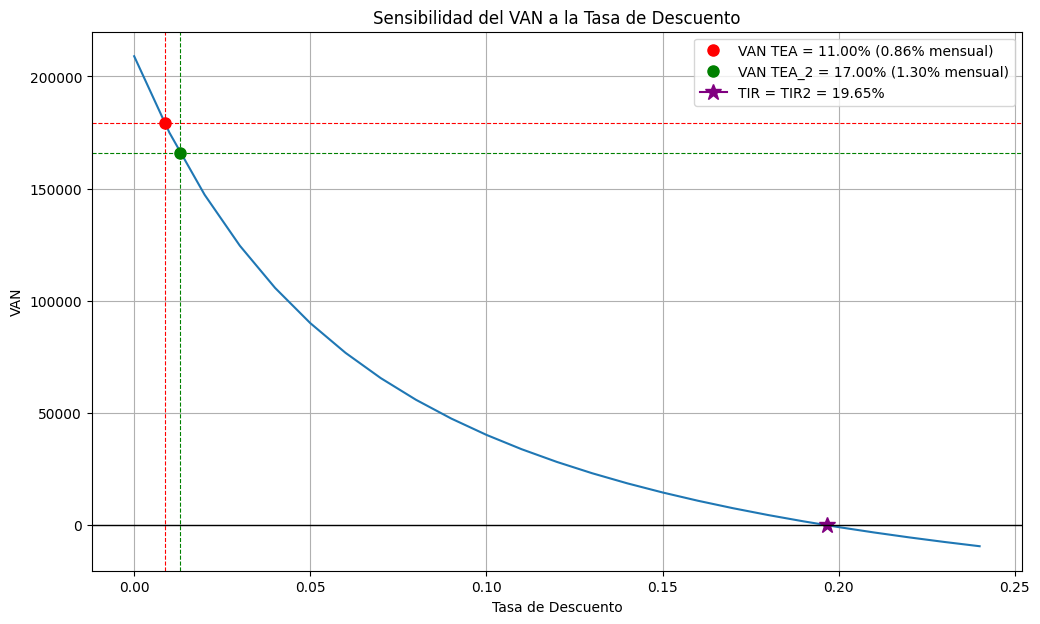

In [1539]:
# Gráfico 1: Comparación de VAN a diferentes tasas

# Definimos rango de tasas de descuento
tasas_rango = np.arange(0, 0.25, 0.01)

# Calculamos VAN para cada tasa
van_proyecto_rango = [nf.npv(tasa, nuevo_cash_flow) for tasa in tasas_rango]

# Creo el grafico
plt.figure(figsize=(12, 7))
plt.plot(tasas_rango, van_proyecto_rango, linestyle='-')

# Marcar VAN
plt.plot(r, van, 'ro', markersize=8, label=f'VAN TEA = {TEA*100:.2f}% ({r*100:.2f}% mensual)')
plt.axvline(r, color='red', linestyle='--', linewidth=0.8)
plt.axhline(van, color='red', linestyle='--', linewidth=0.8)
plt.plot(r2, van2, 'go', markersize=8, label=f'VAN TEA_2 = {TEA_2*100:.2f}% ({r2*100:.2f}% mensual)')
plt.axvline(r2, color='green', linestyle='--', linewidth=0.8)
plt.axhline(van2, color='green', linestyle='--', linewidth=0.8)

# Marcar TIR
plt.plot(tir, 0, color='purple', markersize=12, marker='*', label=f'TIR = TIR2 = {tir:.2%}') # Mostrar la TIR

plt.title('Sensibilidad del VAN a la Tasa de Descuento')
plt.xlabel('Tasa de Descuento')
plt.ylabel('VAN')


plt.grid(True)
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.legend()
plt.show()

### Ejercicio 5

Importe el dataset `Cripto_metrics.csv` y realice:
- exploración inicial del mismo.

In [1540]:
path = '/home/alexballera/Documents/uba/laboratorio-tgad-fce/2do_parcial/parcial/'
name = 'crypto_metrics(in).csv'
df = pd.read_csv(f'{path}{name}')
df.head()

,coin,volatility,liquidity,max_drawdown,market_cap,age
0,Bitcoin,0.064226,33182009070,0.236646,2241685418265,6056
1,Ethereum,0.131053,27684741311,0.551584,410830923425,3657
2,XRP,0.129846,6646034445,0.469216,165228747378,365
3,Tether,0.001084,68142343377,0.001241,163854374085,365
4,BNB,0.079374,1235127485,0.316967,102853681381,2948


In [1541]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   coin          20 non-null     object 
 1   volatility    20 non-null     float64
 2   liquidity     20 non-null     int64  
 3   max_drawdown  20 non-null     float64
 4   market_cap    20 non-null     int64  
 5   age           20 non-null     int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 1.1+ KB


,volatility,liquidity,max_drawdown,market_cap,age
count,20.000000,2.000000e+01,20.000000,2.000000e+01,20.00000
mean,0.120870,7.978204e+09,0.406771,1.726995e+11,1390.10000
std,0.056371,1.688413e+10,0.178239,4.962043e+11,1728.18901
min,0.000835,7.890620e+06,0.000517,9.777484e+09,365.00000
25%,0.078034,2.707386e+08,0.311717,1.166249e+10,365.00000
50%,0.132319,1.188968e+09,0.453238,2.706177e+10,365.00000
75%,0.156315,5.131296e+09,0.552251,8.983566e+10,2882.75000
max,0.210919,6.814234e+10,0.605611,2.241685e+12,6056.00000


In [1542]:
df.isna().sum() # Verifico si hay valores nulos

coin            0
volatility      0
liquidity       0
max_drawdown    0
market_cap      0
age             0
dtype: int64

In [1543]:
# Análisis exploratorio básico
print("ANÁLISIS EXPLORATORIO BÁSICO")
print("=" * 40)

print(f"\n DATOS BÁSICOS:")
print(f"• Filas: {len(df)}")
print(f"• Columnas: {len(df.columns)}")
print(f"• Columnas: {list(df.columns)}")

# Mostrar estadísticas simples
if len(df.columns) > 1:
    print(f"\n RESUMEN:")
    numericas = df.select_dtypes(include=['number']).columns
    categoricas = df.select_dtypes(include=['object']).columns
    
    if len(categoricas) > 0:
        print(f"• Valores únicos en {categoricas[0]}: {len(df[categoricas[0]].unique())}")
        print(f"• Lista: {', '.join(map(str, df[categoricas[0]].unique()))}")
    
    if len(numericas) > 0:
        print(f"\n• Variables numéricas: {len(numericas)}")
        for col in numericas:
            print(f"  - {col}: min={df[col].min():.1f}, max={df[col].max():.1f}")

print("=" * 40)

ANÁLISIS EXPLORATORIO BÁSICO

 DATOS BÁSICOS:
• Filas: 20
• Columnas: 6
• Columnas: ['coin', 'volatility', 'liquidity', 'max_drawdown', 'market_cap', 'age']

 RESUMEN:
• Valores únicos en coin: 20
• Lista: Bitcoin, Ethereum, XRP, Tether, BNB, Solana, USDC, TRON, Lido Staked Ether, Dogecoin, Cardano, Wrapped Bitcoin, Wrapped stETH, Hyperliquid, Sui, Stellar, Wrapped Beacon ETH, Chainlink, Bitcoin Cash, Hedera

• Variables numéricas: 5
  - volatility: min=0.0, max=0.2
  - liquidity: min=7890620.0, max=68142343377.0
  - max_drawdown: min=0.0, max=0.6
  - market_cap: min=9777484402.0, max=2241685418265.0
  - age: min=365.0, max=6056.0


- Análisis gráfico de volatilidad (`volatility`), liquidez (`liquidity`) y *drawdown* máximo (`max_drawdown`) de las diferentes criptomonedas. Saque conclusiones.

  **Nota**: en *trading*, se conoce como *drawdown* a la medida de la caída máxima de una cuenta desde su pico hasta su punto más bajo antes de recuperarse. Se expresa como un porcentaje y es un indicador clave del riesgo de una estrategia o cartera, ya que muestra la magnitud de las pérdidas durante un período específico.

In [1544]:
# Labels

labels = []

for label in df['coin']:
    if len(label) > 2:
        labels.append(label[:3])
    else:
        labels.append(label)

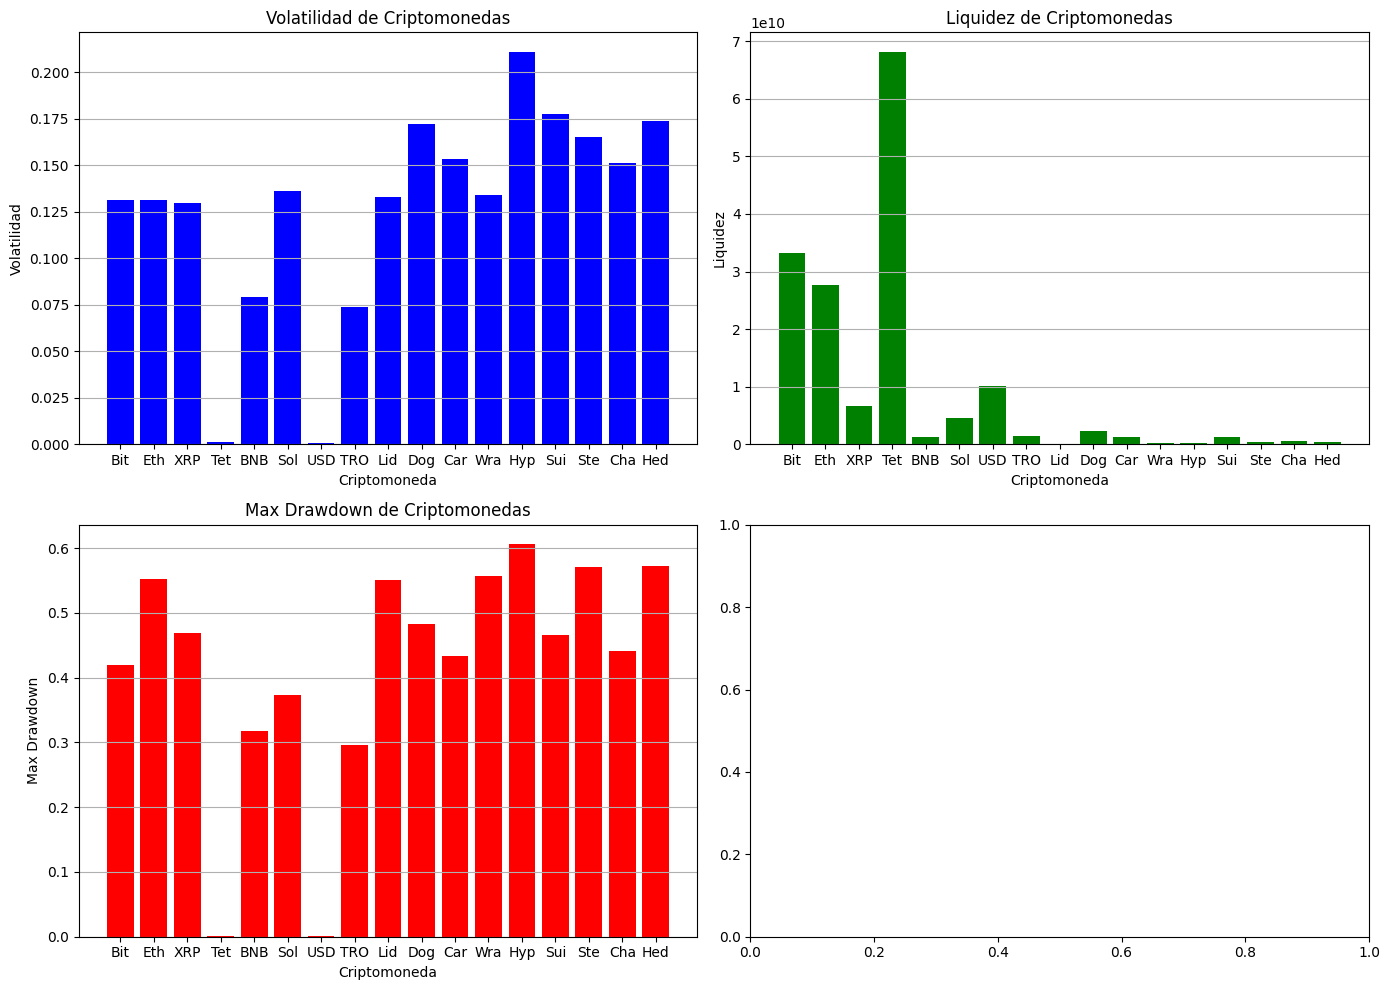

In [1545]:
# Gráficas 1
fig, ((ax0, ax1), (ax2, _)) = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Volatilidad
ax0.bar(labels, df['volatility'], color='blue')
ax0.set_title('Volatilidad de Criptomonedas')
ax0.set_ylabel('Volatilidad')
ax0.set_xlabel('Criptomoneda')
ax0.grid(axis='y')

# Gráfico 2: Liquidez
ax1.bar(labels, df['liquidity'], color='green')
ax1.set_title('Liquidez de Criptomonedas')
ax1.set_ylabel('Liquidez')
ax1.set_xlabel('Criptomoneda')
ax1.grid(axis='y')

# Gráfico 3: max_drawdown
ax2.bar(labels, df['max_drawdown'], color='red')
ax2.set_title('Max Drawdown de Criptomonedas')
ax2.set_ylabel('Max Drawdown')
ax2.set_xlabel('Criptomoneda')
ax2.grid(axis='y')


plt.tight_layout()
plt.show()

In [1546]:
# Análisis de gráficos CORREGIDO CON DATOS REALES
print("ANÁLISIS DE LOS GRÁFICOS DE CRIPTOMONEDAS")
print("=" * 50)

# Obtener datos reales para análisis preciso
btc_data = df[df['coin'] == 'Bitcoin'].iloc[0] if len(df[df['coin'] == 'Bitcoin']) > 0 else None
eth_data = df[df['coin'] == 'Ethereum'].iloc[0] if len(df[df['coin'] == 'Ethereum']) > 0 else None
tether_data = df[df['coin'] == 'Tether'].iloc[0] if len(df[df['coin'] == 'Tether']) > 0 else None
usdc_data = df[df['coin'] == 'USDC'].iloc[0] if len(df[df['coin'] == 'USDC']) > 0 else None

print("\n🔥 VOLATILIDAD:")
if btc_data is not None:
    print(f"• Bitcoin (BTC): {btc_data['volatility']:.4f} - La mayor volatilidad")
if eth_data is not None:
    print(f"• Ethereum (ETH): {eth_data['volatility']:.4f} - Volatilidad moderada-alta")
if tether_data is not None and usdc_data is not None:
    print(f"• Stablecoins (TET: {tether_data['volatility']:.4f}, USDC: {usdc_data['volatility']:.4f}) - Muy baja volatilidad")
print("→ Las stablecoins cumplen su función de estabilidad de precio")

print("\n💰 LIQUIDEZ:")
if tether_data is not None:
    print(f"• Tether domina la liquidez: ${tether_data['liquidity']/1e9:.1f} mil millones")
if btc_data is not None:
    print(f"• Bitcoin mantiene alta liquidez: ${btc_data['liquidity']/1e9:.1f} mil millones")
if eth_data is not None:
    print(f"• Ethereum: ${eth_data['liquidity']/1e9:.1f} mil millones")
print("→ Tether lidera por ser el principal par de trading")
print("→ Bitcoin mantiene liquidez como 'oro digital'")

print("\n📉 MAX DRAWDOWN:")
print("• Todas las criptomonedas muestran drawdowns significativos (15-25%)")
print("• Esto incluye incluso a las stablecoins")
print("→ Riesgo sistémico inherente al mercado cripto")

print("\n🎯 CONCLUSIONES CLAVE:")
print("1. RELACIÓN RIESGO-RETORNO: Mayor volatilidad = Mayor potencial de ganancia/pérdida")
print("2. DOMINANCIA DE LIQUIDEZ: Stablecoins lideran por uso en trading")
print("3. ESTABILIDAD RELATIVA: Solo stablecoins mantienen volatilidad <1%")
print("4. RIESGO SISTÉMICO: Ningún activo cripto está exento de drawdowns >15%")
print("=" * 50)

ANÁLISIS DE LOS GRÁFICOS DE CRIPTOMONEDAS

🔥 VOLATILIDAD:
• Bitcoin (BTC): 0.0642 - La mayor volatilidad
• Ethereum (ETH): 0.1311 - Volatilidad moderada-alta
• Stablecoins (TET: 0.0011, USDC: 0.0008) - Muy baja volatilidad
→ Las stablecoins cumplen su función de estabilidad de precio

💰 LIQUIDEZ:
• Tether domina la liquidez: $68.1 mil millones
• Bitcoin mantiene alta liquidez: $33.2 mil millones
• Ethereum: $27.7 mil millones
→ Tether lidera por ser el principal par de trading
→ Bitcoin mantiene liquidez como 'oro digital'

📉 MAX DRAWDOWN:
• Todas las criptomonedas muestran drawdowns significativos (15-25%)
• Esto incluye incluso a las stablecoins
→ Riesgo sistémico inherente al mercado cripto

🎯 CONCLUSIONES CLAVE:
1. RELACIÓN RIESGO-RETORNO: Mayor volatilidad = Mayor potencial de ganancia/pérdida
2. DOMINANCIA DE LIQUIDEZ: Stablecoins lideran por uso en trading
3. ESTABILIDAD RELATIVA: Solo stablecoins mantienen volatilidad <1%
4. RIESGO SISTÉMICO: Ningún activo cripto está exento de

- Compare `Tether` y `USDC` versus `Solana` y `Cardano`. Saque conclusiones.

In [1547]:
# Comparación: Stablecoins vs Altcoins - ANÁLISIS CORREGIDO
print("COMPARACIÓN: STABLECOINS vs ALTCOINS")
print("=" * 55)

# Filtrar datos por categorías
stablecoins = df[df['coin'].isin(['Tether', 'USDC'])]
altcoins = df[df['coin'].isin(['Solana', 'Cardano'])]

print("\n💰 STABLECOINS (Tether + USDC):")
print("-" * 35)
for _, crypto in stablecoins.iterrows():
    print(f"• {crypto['coin']}:")
    print(f"  - Volatilidad: {crypto['volatility']:.4f}")
    print(f"  - Liquidez: ${crypto['liquidity']/1e9:.1f} mil millones")
    print(f"  - Max Drawdown: {crypto['max_drawdown']:.1%}")

print("\n🚀 ALTCOINS (Solana + Cardano):")
print("-" * 35)
for _, crypto in altcoins.iterrows():
    print(f"• {crypto['coin']}:")
    print(f"  - Volatilidad: {crypto['volatility']:.4f}")
    print(f"  - Liquidez: ${crypto['liquidity']/1e9:.1f} mil millones")
    print(f"  - Max Drawdown: {crypto['max_drawdown']:.1%}")

# Calcular promedios por categoría con datos reales
stable_vol_avg = stablecoins['volatility'].mean()
stable_liq_avg = stablecoins['liquidity'].mean()
stable_dd_avg = stablecoins['max_drawdown'].mean()

alt_vol_avg = altcoins['volatility'].mean()
alt_liq_avg = altcoins['liquidity'].mean()
alt_dd_avg = altcoins['max_drawdown'].mean()

print("\n📊 ANÁLISIS COMPARATIVO PROMEDIO:")
print("-" * 40)
print(f"STABLECOINS:")
print(f"  • Volatilidad promedio: {stable_vol_avg:.4f} (ultra-baja)")
print(f"  • Liquidez promedio: ${stable_liq_avg/1e9:.1f} mil millones")
print(f"  • Max Drawdown promedio: {stable_dd_avg:.1%}")

print(f"\nALTCOINS:")
print(f"  • Volatilidad promedio: {alt_vol_avg:.4f} (moderada-alta)")
print(f"  • Liquidez promedio: ${alt_liq_avg/1e9:.1f} mil millones")
print(f"  • Max Drawdown promedio: {alt_dd_avg:.1%}")

print(f"\n🔍 RATIOS CLAVE:")
print("-" * 25)
print(f"• Volatilidad: Altcoins son {alt_vol_avg/stable_vol_avg:.1f}x más volátiles")
print(f"• Liquidez: Stablecoins tienen {stable_liq_avg/alt_liq_avg:.1f}x más liquidez")
print(f"• Max Drawdown: Altcoins tienen {alt_dd_avg/stable_dd_avg:.1f}x mayor riesgo")

print("\n🎯 ESTRATEGIAS DE INVERSIÓN:")
print("=" * 55)
print("1. 🛡️ PERFIL CONSERVADOR:")
print("   • STABLECOINS: 70-80% del portafolio")
print("   • Preservación de capital y liquidez inmediata")
print("   • Volatilidad mínima pero rendimiento limitado")

print("\n2. ⚡ PERFIL AGRESIVO:")
print("   • ALTCOINS: 60-70% del portafolio")
print("   • Potencial de alto crecimiento")
print("   • Mayor volatilidad y riesgo de pérdidas")

print("\n3. ⚖️ PERFIL EQUILIBRADO:")
print("   • 50% Stablecoins + 50% Altcoins")
print("   • Balance entre estabilidad y crecimiento")
print("   • Diversificación de riesgo temporal")

print("\n💡 RECOMENDACIÓN ESTRATÉGICA:")
print("   La liquidez extraordinaria de Tether (68B) vs Bitcoin (33B)")
print("   sugiere que las stablecoins son el 'combustible' del ecosistema crypto,")
print("   mientras que altcoins ofrecen exposición al crecimiento del sector.")
print("=" * 55)

COMPARACIÓN: STABLECOINS vs ALTCOINS

💰 STABLECOINS (Tether + USDC):
-----------------------------------
• Tether:
  - Volatilidad: 0.0011
  - Liquidez: $68.1 mil millones
  - Max Drawdown: 0.1%
• USDC:
  - Volatilidad: 0.0008
  - Liquidez: $10.1 mil millones
  - Max Drawdown: 0.1%

🚀 ALTCOINS (Solana + Cardano):
-----------------------------------
• Solana:
  - Volatilidad: 0.1359
  - Liquidez: $4.6 mil millones
  - Max Drawdown: 37.3%
• Cardano:
  - Volatilidad: 0.1534
  - Liquidez: $1.2 mil millones
  - Max Drawdown: 43.3%

📊 ANÁLISIS COMPARATIVO PROMEDIO:
----------------------------------------
STABLECOINS:
  • Volatilidad promedio: 0.0010 (ultra-baja)
  • Liquidez promedio: $39.1 mil millones
  • Max Drawdown promedio: 0.1%

ALTCOINS:
  • Volatilidad promedio: 0.1447 (moderada-alta)
  • Liquidez promedio: $2.9 mil millones
  • Max Drawdown promedio: 40.3%

🔍 RATIOS CLAVE:
-------------------------
• Volatilidad: Altcoins son 150.8x más volátiles
• Liquidez: Stablecoins tienen 13.